# I am trying to check my understandability of linear regression using a code implemented below by me.

In [3]:
# Importing the required libraries and the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Creating the dataframe and checking for the first n values

In [5]:
# Load the dataset directly as a frame
digits_data = load_digits(as_frame=True)
df = digits_data.frame # type: ignore

df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


### Exploring the dataset

In [7]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
target       0
Length: 65, dtype: int64

### Define Features and Target

In [10]:
X = df.drop(columns=["target"])  # Features
y = df["target"]                 # Target variable

### Train-Test-Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

### Train Model

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Predictions

In [13]:
y_pred = model.predict(X_test)

### Evaluation

In [14]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.4232045246136245
MSE : 3.259968922611175
RMSE: 1.8055384024193935
R² Score: 0.5779768952989146


### Model Coefficients

In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)

      Feature   Coefficient
0   pixel_0_0 -9.993213e-16
1   pixel_0_1  7.189816e-02
2   pixel_0_2 -4.375006e-03
3   pixel_0_3 -4.555133e-02
4   pixel_0_4  6.324717e-02
..        ...           ...
59  pixel_7_3 -4.849220e-02
60  pixel_7_4 -1.583489e-02
61  pixel_7_5 -6.868290e-02
62  pixel_7_6 -1.697246e-02
63  pixel_7_7 -2.117016e-02

[64 rows x 2 columns]
Intercept: 3.583611927810721


### Actual vs Predicted

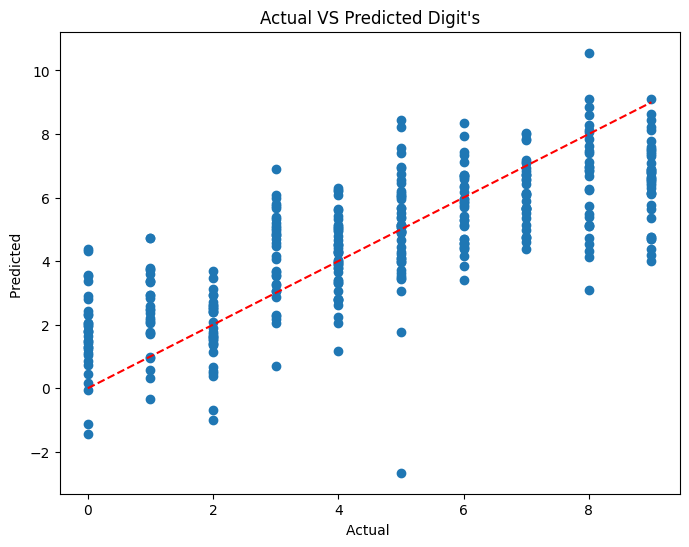

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual ")
plt.ylabel("Predicted ")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--') #perfect line
plt.title("Actual VS Predicted Digit's")
plt.show()